In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from statsmodels.graphics.tsaplots import plot_acf
import calendar

In [7]:
from pandas.tseries.holiday import USFederalHolidayCalendar

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [13]:
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [56]:
def load_and_prep(file_path):
    cols = ['Date', 'Primary Type', 'Arrest', 'Domestic', 'Location Description']
    df = pd.read_csv(file_path, usecols=cols)
    df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')
    df = df[(df['Date'].dt.year >= 2001) & (df['Date'].dt.year <= 2025)]
    df.set_index('Date', inplace=True)
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Hour'] = df.index.hour
    df['DayOfWeek'] = df.index.day_name()
    df['DayNum'] = df.index.dayofweek 
    return df

In [24]:
data_path = 'Crimes_2001.csv' 
df = load_and_prep(data_path)

In [104]:
def plot_basic_distributions(df):
    fig, axes = plt.subplots(4, 1, figsize=(15, 25))
    
    df.resample('Y').size().plot(ax=axes[0], marker='o', color='darkblue', linewidth=2)
    axes[0].set_title('Annual Crime Trend (2001 - Present)')
    axes[0].set_ylabel('Total Crimes')
    
    sns.countplot(data=df, x='Month', ax=axes[1], hue='Month', palette='viridis', legend=False)
    axes[1].set_title('Monthly Seasonality')
    axes[1].set_xticks(range(0, 12))
    axes[1].set_xticklabels([calendar.month_name[i] for i in range(1, 13)])
    
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.countplot(data=df, x='DayOfWeek', order=day_order, ax=axes[2], hue='DayOfWeek', palette='magma', legend=False)
    axes[2].set_title('Weekly Cycle')

    sns.countplot(data=df, x='Hour', ax=axes[3], hue=df.index.hour, palette='coolwarm', legend=False)
    axes[3].set_title('Hourly Distribution')
    axes[3].set_xlabel('Hour of Day')
    
    plt.tight_layout()
    plt.show()

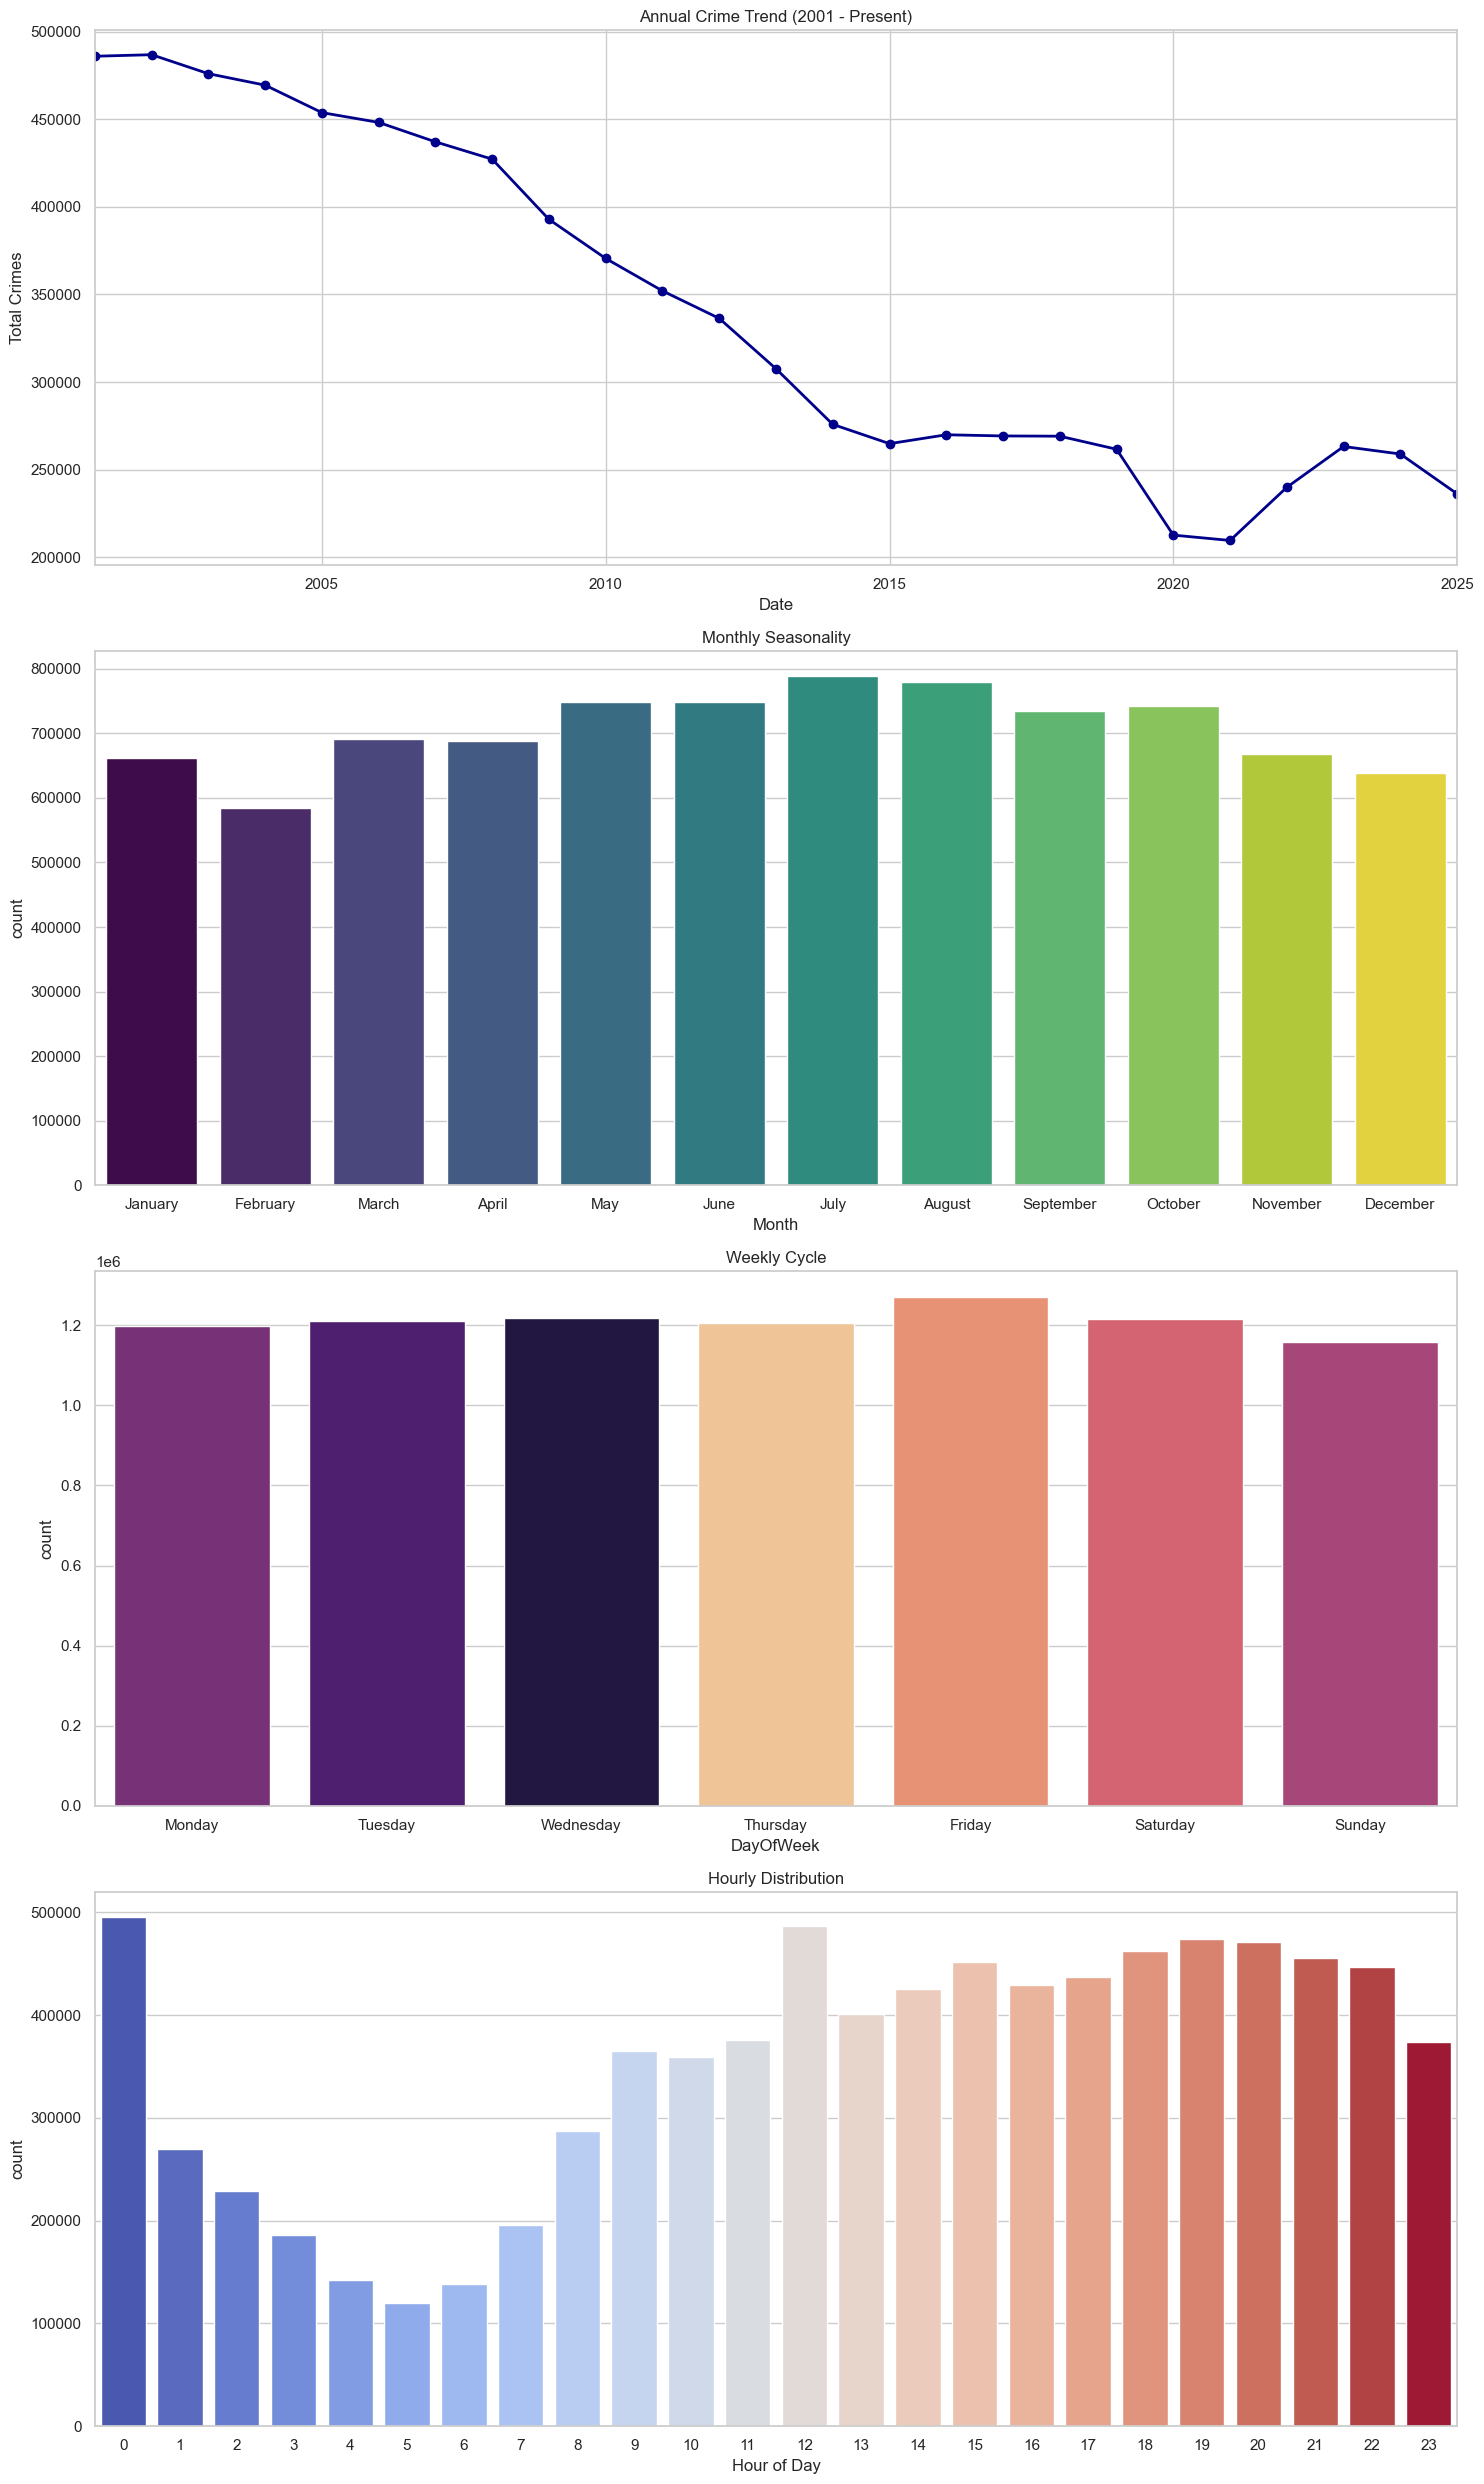

In [106]:
plot_basic_distributions(df)

In [8]:
def plot_crime_time(df):
    top_types = df['Primary Type'].value_counts().nlargest(5).index
    subset = df[df['Primary Type'].isin(top_types)]
    pivot = subset.groupby(['Hour', 'Primary Type']).size().unstack()
    pivot_norm = pivot / pivot.sum() 
    
    pivot_norm.plot(figsize=(15, 6), linewidth=3)
    plt.title('When do specific crimes happen?')
    plt.ylabel('Relative Probability Density')
    plt.show()

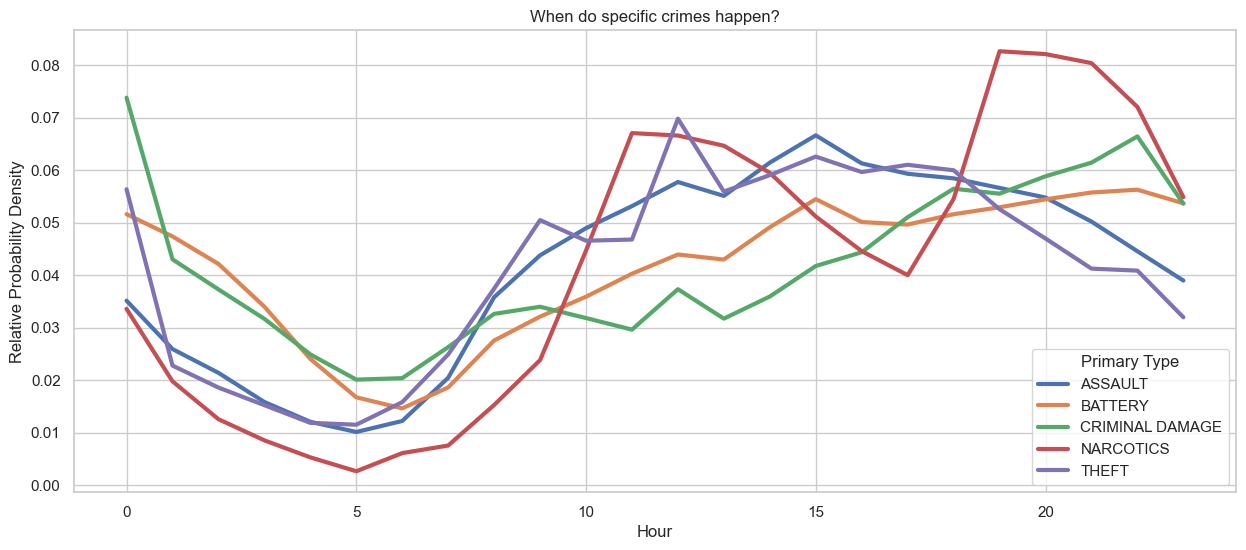

In [9]:
plot_crime_time(df)

In [23]:
def plot_inter_arrival_cdf(df):
    fig, ax = plt.subplots(figsize=(15, 6))
    top5_types = df['Primary Type'].value_counts().nlargest(5).index
    for crime_type in top5_types:
        dates = df[df['Primary Type'] == crime_type].index.sort_values()
        diffs = dates.to_series().diff().dt.total_seconds() / 3600
        
        sns.ecdfplot(diffs.dropna(), ax=ax, label=crime_type, linewidth=2.5)
    
    ax.set_xlim(0, 12)  
    ax.set_title('Cumulative Probability of Inter-arrival Time')
    ax.set_xlabel('Hours between successive crimes')
    ax.set_ylabel('Cumulative Probability')
    ax.legend(title="Crime Type")
    
    plt.show()

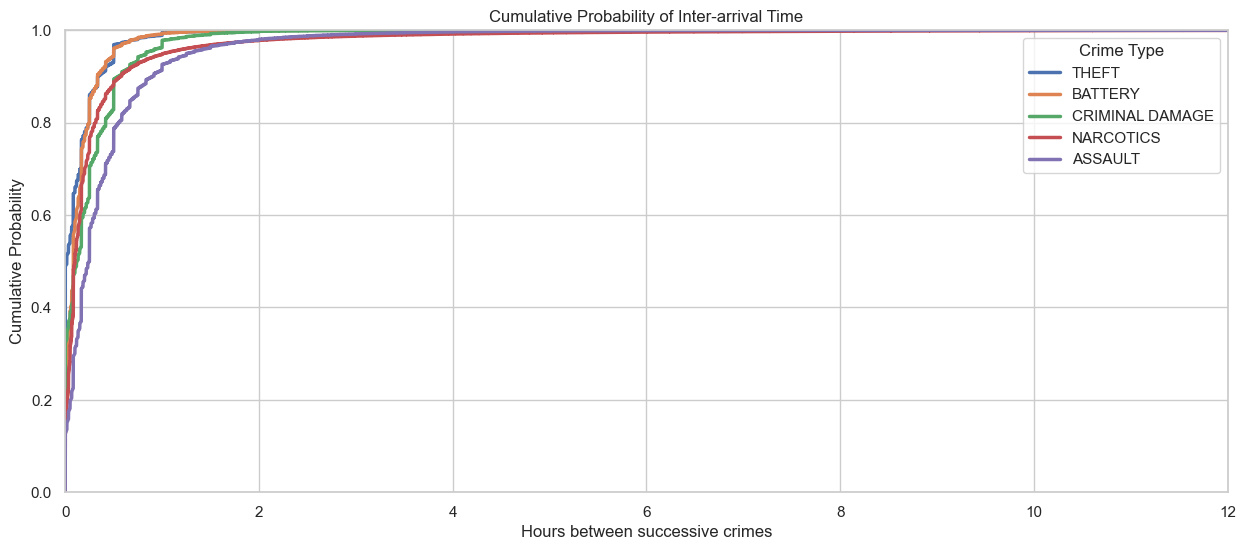

In [24]:
plot_inter_arrival_cdf(df)

In [26]:
def plot_memory(df):
    daily_counts = df.resample('D').size()
    plt.figure(figsize=(15, 5))
    plot_acf(daily_counts, lags=60, ax=plt.gca())
    plt.title('Autocorrelation')
    plt.show()

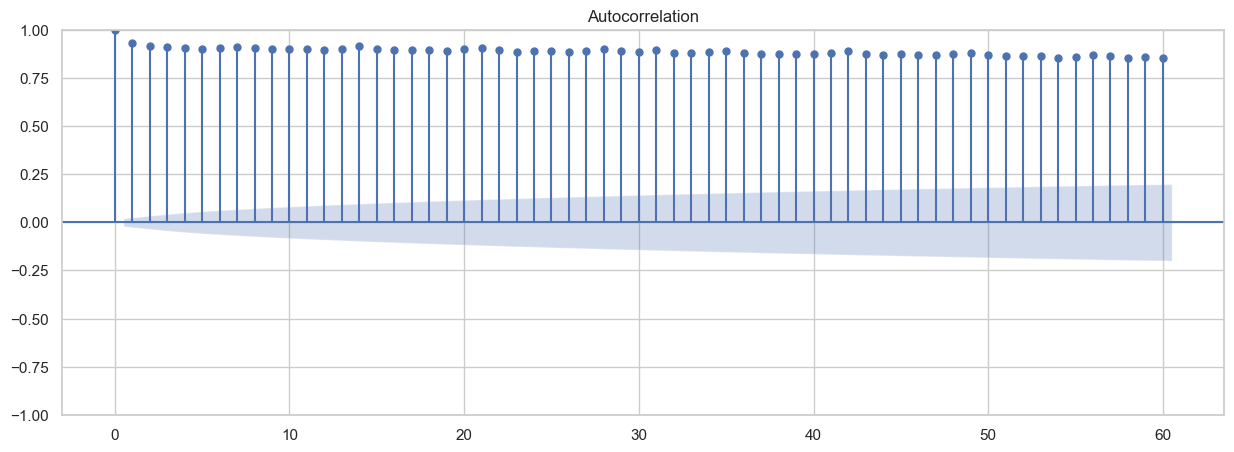

In [27]:
plot_memory(df)

In [28]:
def plot_diff(df):
    daily_counts = df.resample('D').size()
    daily_diff = daily_counts.diff().dropna()
    plt.figure(figsize=(15, 5))
    plot_acf(daily_diff, lags=30)
    plt.title('ACF of Daily Crime Changes (After Differencing)')
    plt.show()

<Figure size 1500x500 with 0 Axes>

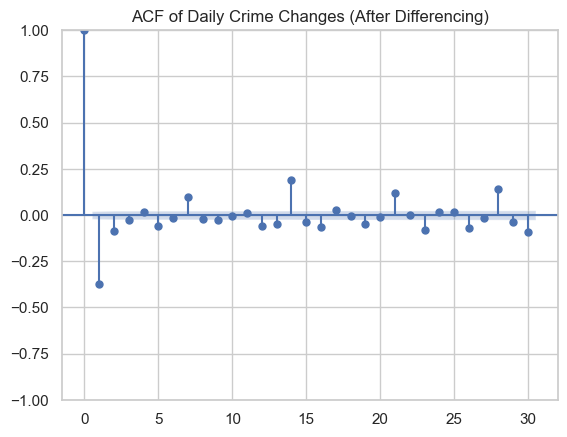

In [29]:
plot_diff(df)

In [32]:
def plot_residuals(df):
    daily_series = df.resample('D').size()
    result = seasonal_decompose(daily_series, model='additive', period=365)
    fig, ax = plt.subplots(figsize=(15, 6))
    result.resid.plot(ax=ax, color='red', marker='.', markersize=3, linestyle='None', alpha=0.6)

    ax.set_title('Crime Data Residuals')
    ax.set_ylabel('Residual Value (Unexplained Count)')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5) 
    
    resid_std = result.resid.std()
    ax.axhline(3 * resid_std, color='gray', linestyle=':', alpha=0.5, label='3rd Sigma')
    ax.axhline(-3 * resid_std, color='gray', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    return result

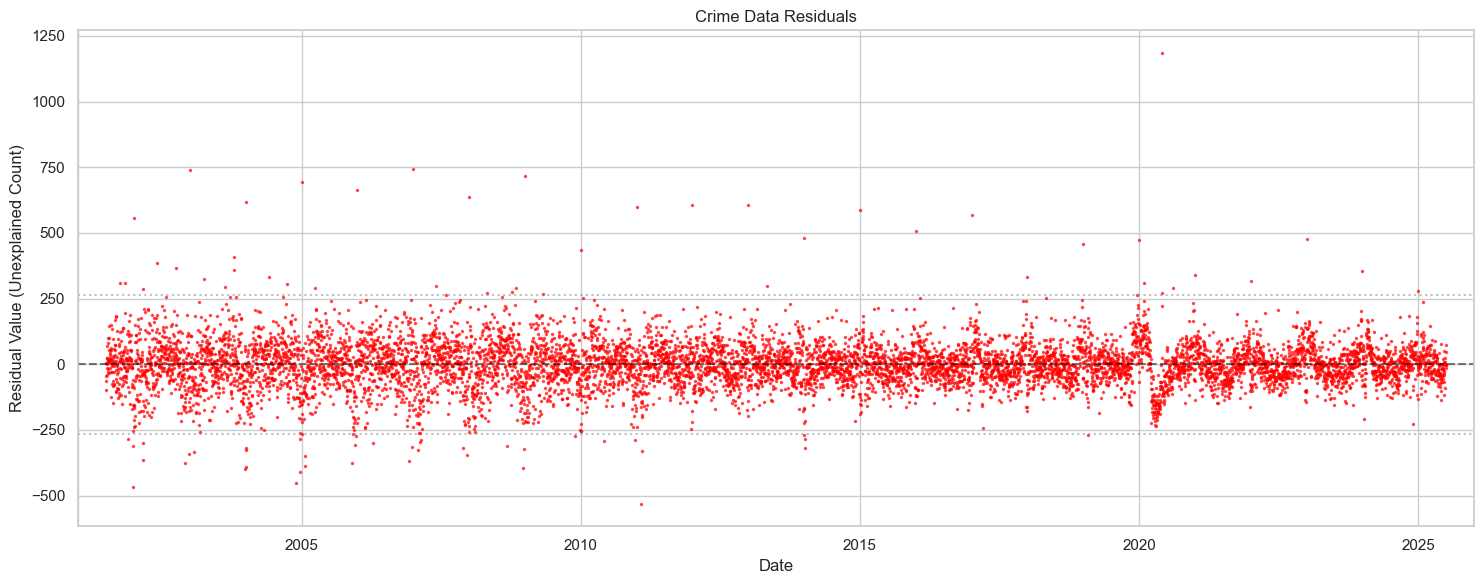

In [33]:
result = plot_residuals(df)

--- outliers ---
Date
2020-05-31    1185.385703
2007-01-01     741.689242
2003-01-01     739.836274
2009-01-01     717.783877
2005-01-01     692.467324
2006-01-01     662.220749
2008-01-01     636.354995
2004-01-01     617.871890
2013-01-01     605.374288
2012-01-01     605.090726
Name: resid, dtype: float64


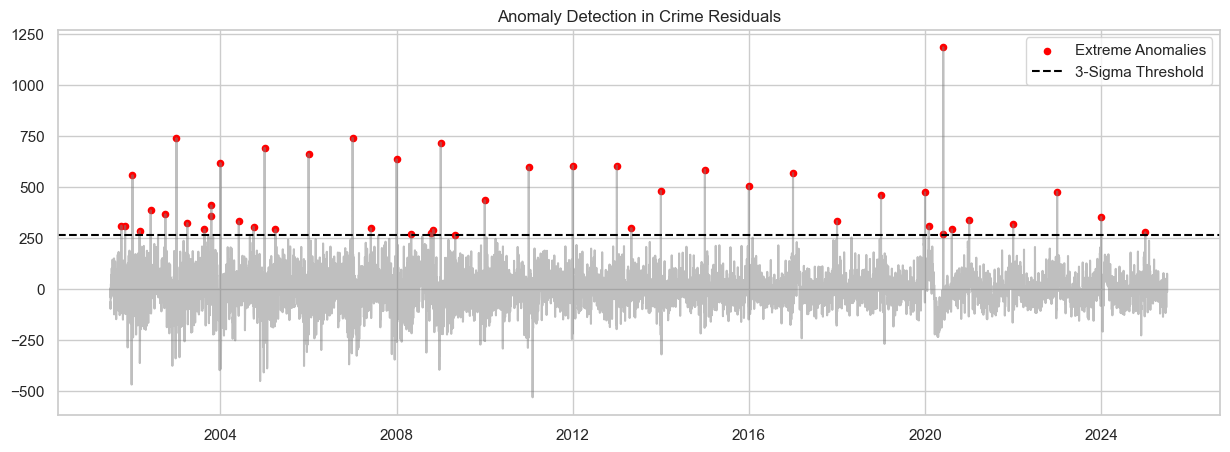

In [35]:
resid = result.resid.dropna()
threshold = resid.mean() + 3 * resid.std()
outliers = resid[resid > threshold]

print("--- outliers ---")
print(outliers.sort_values(ascending=False).head(10))

plt.figure(figsize=(15, 5))
plt.plot(resid, color='gray', alpha=0.5)
plt.scatter(outliers.index, outliers.values, color='red', s=20, label='Extreme Anomalies')
plt.axhline(threshold, color='black', linestyle='--', label='3-Sigma Threshold')
plt.title('Anomaly Detection in Crime Residuals')
plt.legend()
plt.show()

In [38]:
def mark_holidays(df):
    cal = USFederalHolidayCalendar()
    holidays = cal.holidays(start=df.index.min(), end=df.index.max())
    
    df['Is_Holiday'] = df.index.normalize().isin(holidays)
    
    df['Is_Holiday_Window'] = False
    for h in holidays:
        window = pd.date_range(start=h - pd.Timedelta(days=2), end=h + pd.Timedelta(days=7))
        df.loc[df.index.normalize().isin(window), 'Is_Holiday_Window'] = True
    
    df['Period_Type'] = 'Normal Day'
    df.loc[df['Is_Holiday_Window'], 'Period_Type'] = 'Holiday Window'
    df.loc[df['Is_Holiday'], 'Period_Type'] = 'Holiday Day'
    
    return df

In [39]:
def plot_holiday_comparison(df):
    
    top_crimes = df['Primary Type'].value_counts().nlargest(5).index
    subset = df[df['Primary Type'].isin(top_crimes)]
    
    composition = subset.groupby(['Period_Type', 'Primary Type']).size().unstack()
    composition_pct = composition.div(composition.sum(axis=1), axis=0)
    
    plt.figure(figsize=(12, 6))
    composition_pct.plot(kind='bar', stacked=True, colormap='Spectral', figsize=(12, 7))
    plt.title('Crime Composition: Holiday vs. Normal Days', fontsize=14)
    plt.ylabel('Percentage of Total Crimes')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

<Figure size 1200x600 with 0 Axes>

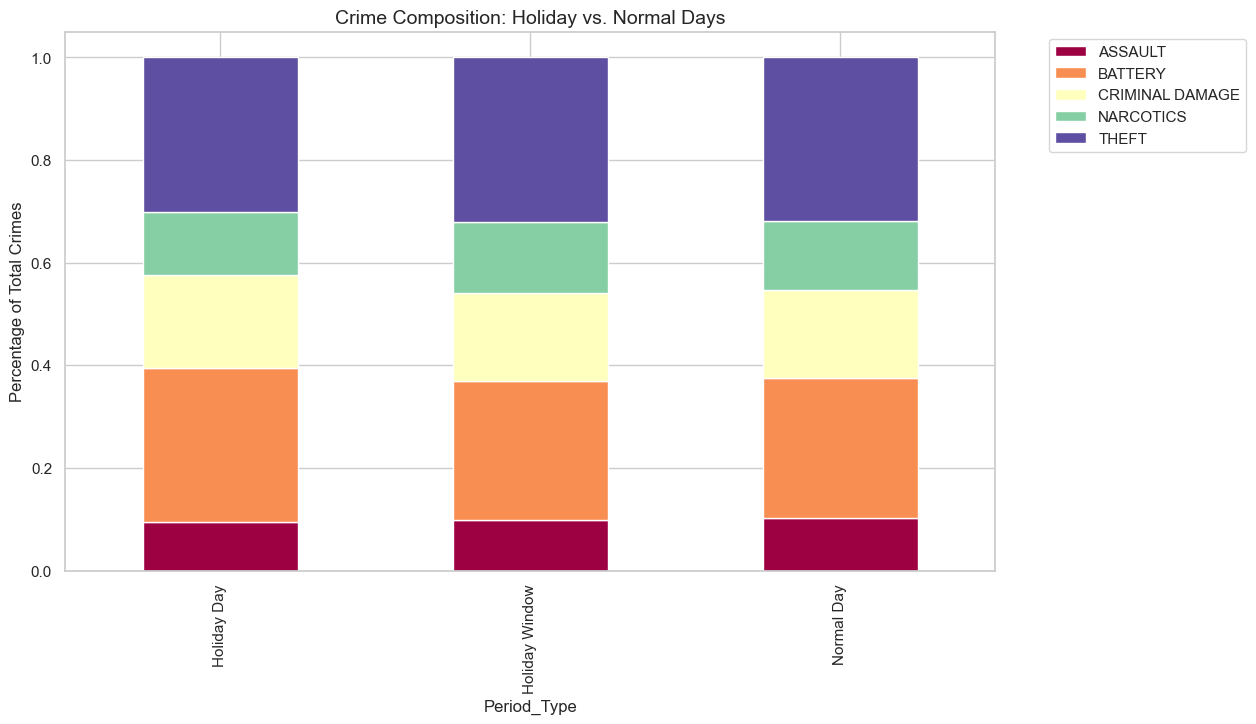

In [40]:
df_holiday = mark_holidays(df)
plot_holiday_comparison(df_holiday)

In [42]:
def plot_holiday_hourly_pulse(df):
    plt.figure(figsize=(12, 5))
    for p_type in ['Holiday Day', 'Normal Day']:
        data = df[df['Period_Type'] == p_type]
        hourly_dist = data['Hour'].value_counts(normalize=True).sort_index()
        plt.plot(hourly_dist.index, hourly_dist.values, label=p_type, linewidth=2.5)
    
    plt.title('Hourly Crime Pulse: Is Holiday Night more Dangerous?', fontsize=14)
    plt.xlabel('Hour of Day')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.show()

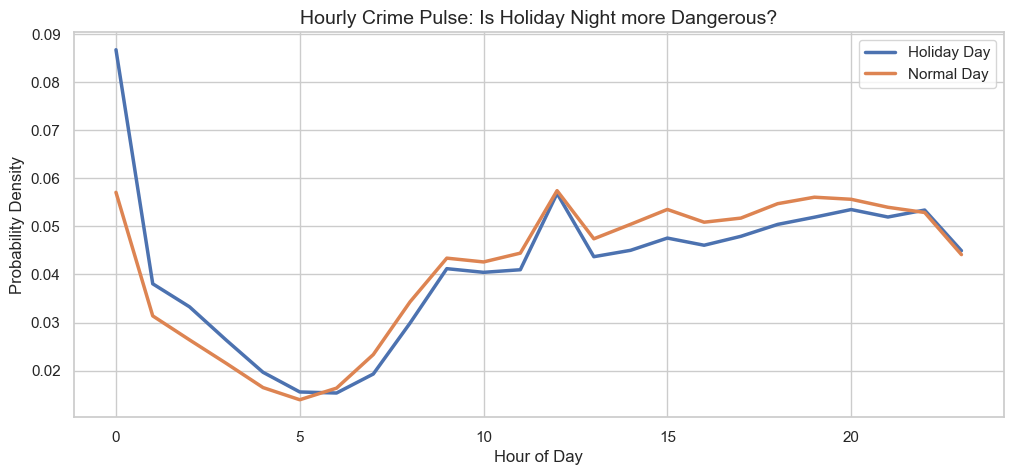

In [43]:
plot_holiday_hourly_pulse(df_holiday)

In [19]:
df['Location Description'].value_counts().nlargest(8)

Location Description
STREET                            2214772
RESIDENCE                         1389578
APARTMENT                         1011627
SIDEWALK                           764806
OTHER                              269926
PARKING LOT/GARAGE(NON.RESID.)     202922
ALLEY                              188583
SMALL RETAIL STORE                 171254
Name: count, dtype: int64

In [20]:
def plot_location_shift(df):
    locations = ['STREET', 'RESIDENCE', 'APARTMENT']
    subset = df[df['Location Description'].isin(locations)]
    pivot = subset.groupby(['Hour', 'Location Description']).size().unstack()
    
    plt.figure(figsize=(15, 6))
    sns.heatmap(pivot.T, cmap='YlGnBu')
    plt.title('6. Spatio-Temporal Shift')
    plt.show()

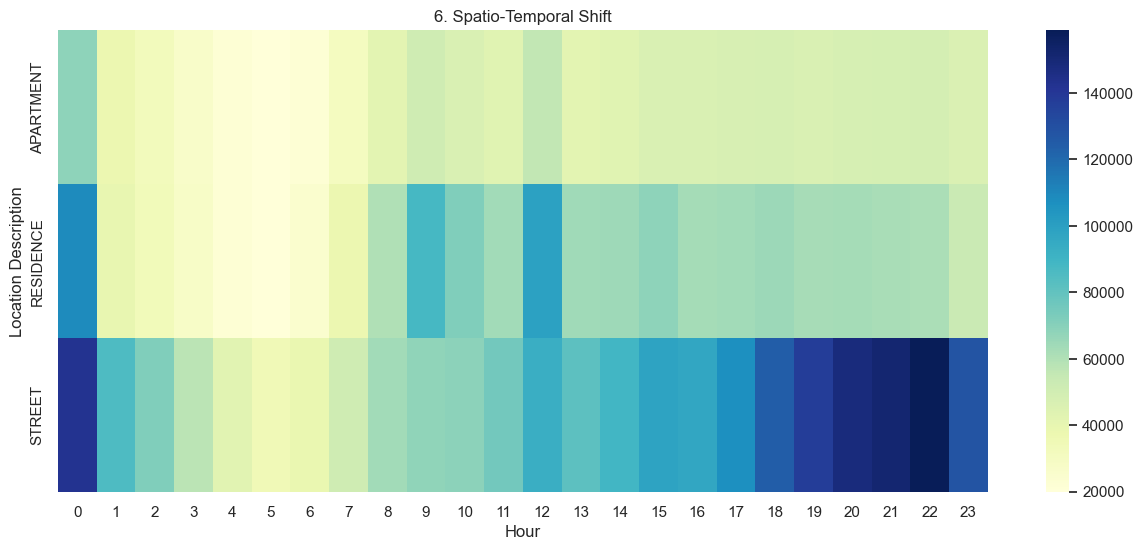

In [21]:
plot_location_shift(df)

In [11]:
def plot_arrest_efficiency(df):
    arrest_rate = df.groupby('Year')['Arrest'].mean()
    plt.figure(figsize=(15, 5))
    arrest_rate.plot(kind='line', marker='s', color='green', linewidth=2)
    plt.title(' Historical Arrest Rate')
    plt.ylabel('Arrest Success Rate')
    plt.show()

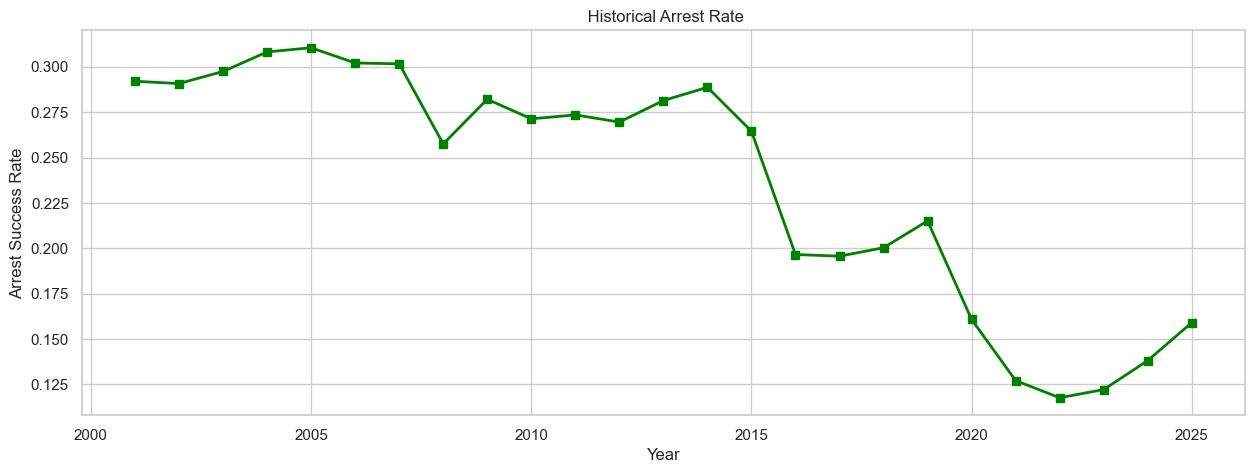

In [12]:
plot_arrest_efficiency(df)

In [86]:
def plot_crime_structure(df):
    top5_crimes = df['Primary Type'].value_counts().nlargest(5).index
    df_top5 = df[df['Primary Type'].isin(top5_crimes)]
    
    crime_counts = df_top5.groupby(['Year', 'Primary Type']).size().unstack(fill_value=0)
    crime_ratio = crime_counts.div(crime_counts.sum(axis=1), axis=0)
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 15))
    
    crime_ratio.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
    axes[0].set_title('Crime Type Structure Over Time (Stacked Area)')
    axes[0].set_ylabel('Proportion of Top5 Crimes')
    axes[0].legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    crime_counts.plot(kind='line', marker='s', ax=axes[1], linewidth=2)
    axes[1].set_title('Crime Count by Type Over Time')
    axes[1].set_ylabel('Number of Cases')
    axes[1].legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

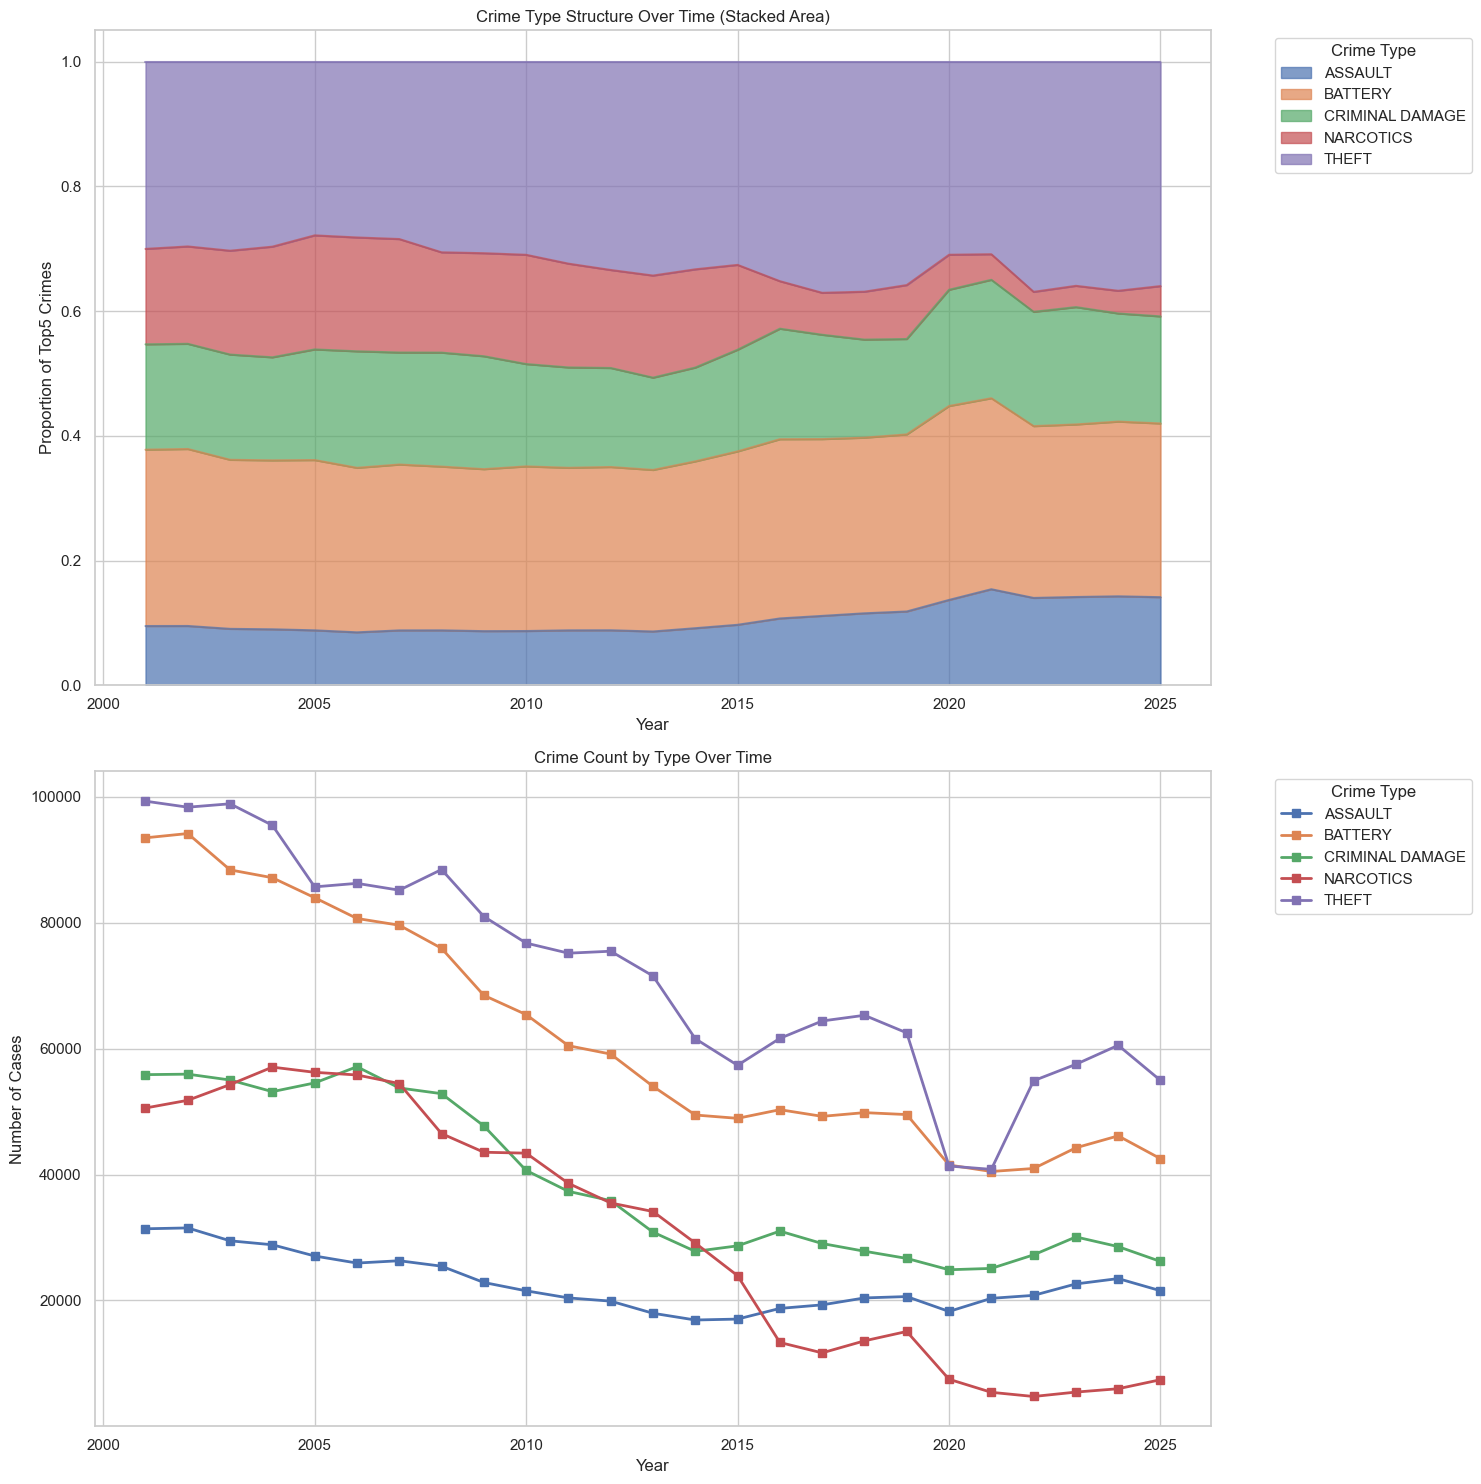

In [88]:
plot_crime_structure(df)